<a href="https://colab.research.google.com/github/adithya-ashoks/deep-learning-practice/blob/main/Early_Stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import tensorflow  as tf
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [4]:
x,y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

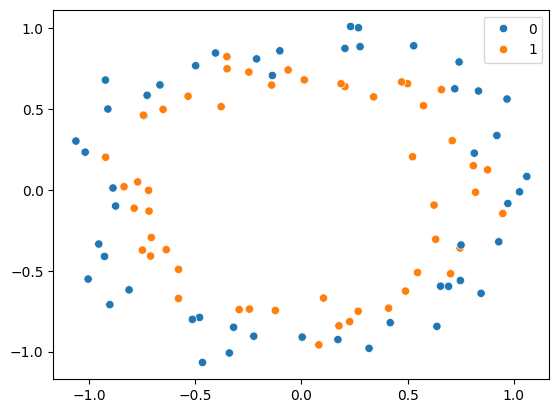

In [5]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 2)

In [7]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
history = model.fit(x_train, y_train, epochs=3500, validation_data=(x_test,y_test), verbose = 0)

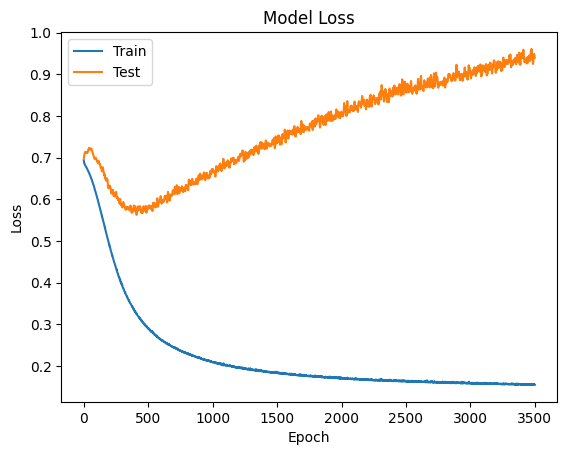

In [10]:
plt.plot(history.history['loss'],label = "train")
plt.plot(history.history['val_loss'], label = "test")
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


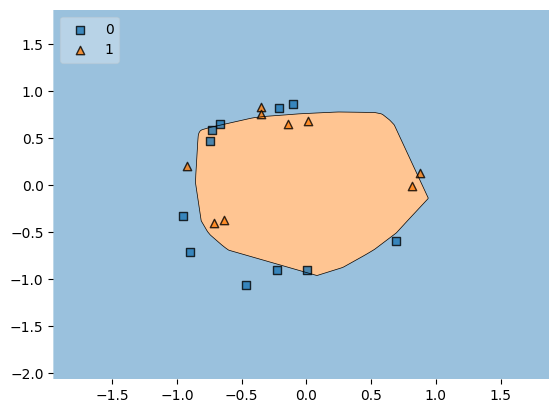

In [11]:
plot_decision_regions(x_test, y_test, clf=model , legend =2)
plt.show()

Early Stopping


In [12]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
callback = EarlyStopping(monitor='val_loss',
                         min_delta=0.00001,
                         patience=20,
                         verbose =1,
                         mode = "auto",
                         baseline = None,
                         restore_best_weights = False)

In [15]:
history = model.fit(x_train, y_train, epochs=3500, validation_data=(x_test,y_test), callbacks=[callback])

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.4375 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4875 - loss: 0.6921 - val_accuracy: 0.4000 - val_loss: 0.6965
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6905 - val_accuracy: 0.4000 - val_loss: 0.6986
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5500 - loss: 0.6894 - val_accuracy: 0.4000 - val_loss: 0.7002
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5500 - loss: 0.6886 - val_accuracy: 0.4000 - val_loss: 0.7027
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5750 - loss: 0.6875 - val_accuracy: 0.4000 - val_loss: 0.7045
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5750 - loss: 0.6866 - val_accuracy: 0.4000 - val_loss: 0.7054
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5750 - loss: 0.6857 - val_accuracy: 0.4000 - 

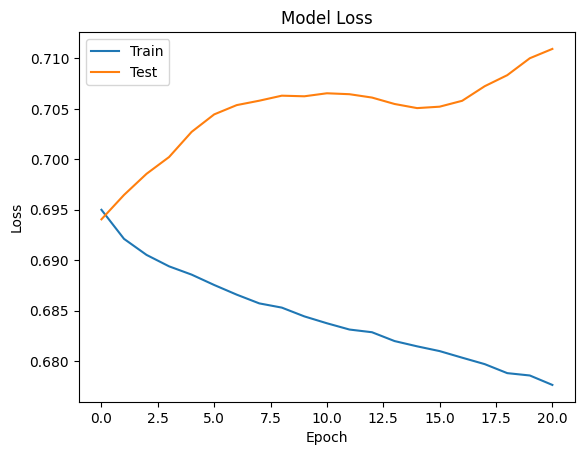

In [16]:
plt.plot(history.history['loss'],label = "train")
plt.plot(history.history['val_loss'], label = "test")
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


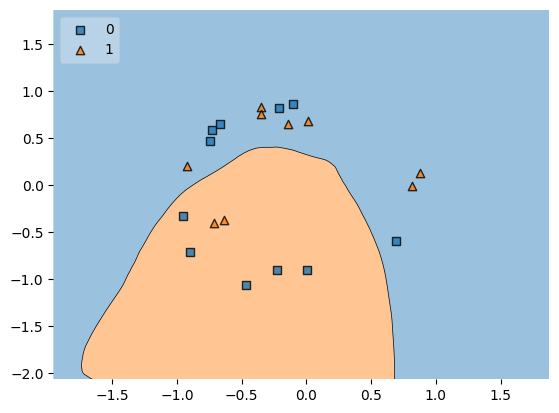

In [17]:
plot_decision_regions(x_test, y_test, clf=model , legend =2)
plt.show()